# Using Ragas to Evaluate a RAG Application built with LangChain and LangGraph

In the following notebook, we'll be looking at how [Ragas](https://github.com/explodinggradients/ragas) can be helpful in a number of ways when looking to evaluate your RAG applications!

While this example is rooted in LangChain/LangGraph - Ragas is framework agnostic (you don't even need to be using a framework!).

- 🤝 Breakout Room #1
  1. Task 1: Installing Required Libraries
  2. Task 2: Set Environment Variables
  3. Task 3: Synthetic Dataset Generation for Evaluation using Ragas
  4. Task 4: Evaluating our Pipeline with Ragas
  5. Task 6: Making Adjustments and Re-Evaluating

But first! Let's set some dependencies!

## Dependencies and API Keys:

We'll also need to provide our API keys.

First, OpenAI's for our LLM/embedding model combination!

In [1]:
import os
from getpass import getpass
os.environ["OPENAI_API_KEY"] = getpass("Please enter your OpenAI API key!")

## Generating Synthetic Test Data

We wil be using Ragas to build out a set of synthetic test questions, references, and reference contexts. This is useful because it will allow us to find out how our system is performing.

> NOTE: Ragas is best suited for finding *directional* changes in your LLM-based systems. The absolute scores aren't comparable in a vacuum.

### Data Preparation

We'll prepare our data - which should hopefull be familiar at this point since it's our Loan Data use-case!

Next, let's load our data into a familiar LangChain format using the `DirectoryLoader`.

In [2]:
from langchain_community.document_loaders import DirectoryLoader
from langchain_community.document_loaders import PyMuPDFLoader


path = "data/"
loader = DirectoryLoader(path, glob="*.pdf", loader_cls=PyMuPDFLoader)
docs = loader.load()

### Knowledge Graph Based Synthetic Generation

Ragas uses a knowledge graph based approach to create data. This is extremely useful as it allows us to create complex queries rather simply. The additional testset complexity allows us to evaluate larger problems more effectively, as systems tend to be very strong on simple evaluation tasks.

Let's start by defining our `generator_llm` (which will generate our questions, summaries, and more), and our `generator_embeddings` which will be useful in building our graph.

### Abstracted SDG

The above method is the full process - but we can shortcut that using the provided abstractions!

This will generate our knowledge graph under the hood, and will - from there - generate our personas and scenarios to construct our queries.



In [3]:
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import ChatOpenAI
from langchain_openai import OpenAIEmbeddings
generator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4.1"))
generator_embeddings = LangchainEmbeddingsWrapper(OpenAIEmbeddings())

/Users/rbblankson34/Documents/Projects/AIE8/08_Evaluating_RAG_With_Ragas/.venv/lib/python3.13/site-packages/pysbd/segmenter.py:66: SyntaxWarning: invalid escape sequence '\s'
  for match in re.finditer('{0}\s*'.format(re.escape(sent)), self.original_text):
/Users/rbblankson34/Documents/Projects/AIE8/08_Evaluating_RAG_With_Ragas/.venv/lib/python3.13/site-packages/pysbd/lang/arabic.py:29: SyntaxWarning: invalid escape sequence '\.'
  txt = re.sub('(?<={0})\.'.format(am), '∯', txt)
/Users/rbblankson34/Documents/Projects/AIE8/08_Evaluating_RAG_With_Ragas/.venv/lib/python3.13/site-packages/pysbd/lang/persian.py:29: SyntaxWarning: invalid escape sequence '\.'
  txt = re.sub('(?<={0})\.'.format(am), '∯', txt)


In [4]:
from ragas.testset import TestsetGenerator

generator = TestsetGenerator(llm=generator_llm, embedding_model=generator_embeddings)
dataset = generator.generate_with_langchain_docs(docs, testset_size=10)

Applying HeadlinesExtractor:   0%|          | 0/21 [00:00<?, ?it/s]

Applying HeadlineSplitter:   0%|          | 0/64 [00:00<?, ?it/s]

unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to ap

Applying SummaryExtractor:   0%|          | 0/39 [00:00<?, ?it/s]

Property 'summary' already exists in node 'ef5170'. Skipping!
Property 'summary' already exists in node '92db87'. Skipping!
Property 'summary' already exists in node '011dda'. Skipping!
Property 'summary' already exists in node 'f198a0'. Skipping!
Property 'summary' already exists in node '1d306b'. Skipping!
Property 'summary' already exists in node '9fad09'. Skipping!
Property 'summary' already exists in node '4e6d7b'. Skipping!
Property 'summary' already exists in node '5ecb51'. Skipping!
Property 'summary' already exists in node '166d03'. Skipping!
Property 'summary' already exists in node 'ed21f0'. Skipping!
Property 'summary' already exists in node '20313c'. Skipping!
Property 'summary' already exists in node '69f363'. Skipping!
Property 'summary' already exists in node '968d41'. Skipping!
Property 'summary' already exists in node 'e7b536'. Skipping!
Property 'summary' already exists in node '16728b'. Skipping!
Property 'summary' already exists in node 'ed4909'. Skipping!
Property

...

Property 'summary_embedding' already exists in node '20313c'. Skipping!
Property 'summary_embedding' already exists in node '968d41'. Skipping!
Property 'summary_embedding' already exists in node '69f363'. Skipping!
Property 'summary_embedding' already exists in node 'e7b536'. Skipping!
Property 'summary_embedding' already exists in node '92db87'. Skipping!
Property 'summary_embedding' already exists in node 'ed21f0'. Skipping!
Property 'summary_embedding' already exists in node 'ef5170'. Skipping!
Property 'summary_embedding' already exists in node 'f198a0'. Skipping!
Property 'summary_embedding' already exists in node 'ed4909'. Skipping!
Property 'summary_embedding' already exists in node '5ecb51'. Skipping!
Property 'summary_embedding' already exists in node '011dda'. Skipping!
Property 'summary_embedding' already exists in node '1d306b'. Skipping!
Property 'summary_embedding' already exists in node '9fad09'. Skipping!
Property 'summary_embedding' already exists in node 'e97621'. Sk

Applying [CosineSimilarityBuilder, OverlapScoreBuilder]:   0%|          | 0/2 [00:00<?, ?it/s]

Generating personas:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Scenarios:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Samples:   0%|          | 0/8 [00:00<?, ?it/s]

In [5]:
dataset.to_pandas()

,user_input,reference_contexts,reference,synthesizer_name
0,how many people use chatgpt in july 2025 and h...,[Introduction ChatGPT launched in November 202...,"By July 2025, 700 million users were sending 1...",single_hop_specifc_query_synthesizer
1,whaat hapened with chatgpt in 2024?,[Introduction ChatGPT launched in November 202...,"In late 2024, 28% of US adults used ChatGPT, h...",single_hop_specifc_query_synthesizer
2,"what SOC2 code 19 mean for job type, i not sur...",[Variation by Occupation Figure 23 presents va...,SOC2 code 19 in the context refers to engineer...,single_hop_specifc_query_synthesizer
3,what is Generalized Work Activities and how it...,[Variation by Occupation Figure 23 presents va...,Generalized Work Activities (GWAs) are the mos...,single_hop_specifc_query_synthesizer
4,how chatgpt use different for jobs and what ag...,[<1-hop>\n\nVariation by Occupation Figure 23 ...,"chatgpt use is different by job, with people i...",multi_hop_abstract_query_synthesizer
5,How does the rapid adoption and growth of Chat...,[<1-hop>\n\nVariation by Occupation Figure 23 ...,"The rapid adoption and growth of ChatGPT, with...",multi_hop_abstract_query_synthesizer
6,how chatgpt use different for job and what age...,[<1-hop>\n\nVariation by Occupation Figure 23 ...,chatgpt use for work is much higher in profess...,multi_hop_abstract_query_synthesizer
7,How does ChatGPT adoption and usage vary by oc...,[<1-hop>\n\nVariation by Occupation Figure 23 ...,ChatGPT adoption and usage vary significantly ...,multi_hop_abstract_query_synthesizer


## LangChain RAG

Now we'll construct our LangChain RAG, which we will be evaluating using the above created test data!

### R - Retrieval

Let's start with building our retrieval pipeline, which will involve loading the same data we used to create our synthetic test set above.

> NOTE: We need to use the same data - as our test set is specifically designed for this data.

In [6]:
path = "data/"
loader = DirectoryLoader(path, glob="*.pdf", loader_cls=PyMuPDFLoader)
docs = loader.load()

Now that we have our data loaded, let's split it into chunks!

In [7]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(chunk_size=50, chunk_overlap=0)
split_documents = text_splitter.split_documents(docs)
len(split_documents)

3122

#### ❓ Question: 

What is the purpose of the `chunk_overlap` parameter in the `RecursiveCharacterTextSplitter`?

✅ Answer:

## Purpose of the `chunk_overlap` Parameter in RecursiveCharacterTextSplitter?

The `chunk_overlap` parameter in the `RecursiveCharacterTextSplitter` serves to **preserve context continuity between adjacent text chunks** by creating overlapping content at the boundaries of each chunk. When documents are split into chunks, important information might be split across chunk boundaries. The overlap ensures that context from the end of one chunk is preserved at the beginning of the next chunk.

## Key Functions

1. **Context Preservation**: Maintains important information that might be split across chunk boundaries, ensuring no critical context is lost during the chunking process.

2. **Improved Retrieval Quality**: Enhances the system's ability to capture relevant information during retrieval, as queries might match content that spans across what would otherwise be separate, disconnected chunks.

3. **Semantic Continuity**: Helps maintain semantic relationships between sentences and paragraphs that might be artificially separated by the chunking process.

4. **Enhanced Question Answering**: Improves performance when answers require information from multiple adjacent sections of the original document.

## Advantages

1. **Context Preservation**: Maintains semantic relationships that span chunk boundaries
2. **Improved Retrieval Accuracy**: Increases chances of capturing relevant information during vector search
3. **Reduced Information Loss**: Prevents important context from being lost at artificial boundaries
4. **Better Question Answering**: Helps when answers require information from multiple adjacent sections
5. **Semantic Continuity**: Maintains narrative flow and logical connections in text
6. **Robustness**: Makes the system more resilient to suboptimal chunk boundary placement

## Disadvantages

1. **Increased Storage Requirements**: Overlapping content means storing duplicate information in the vector database
2. **Higher Processing Costs**: More chunks to embed and index, leading to increased computational overhead
3. **Potential Redundancy**: Same information may be retrieved multiple times in search results
4. **Slower Indexing**: More content to process during initial setup and embedding generation
5. **Memory Overhead**: Larger vector stores require more memory resources
6. **Cost Implications**: Higher embedding API costs due to processing duplicate content

## Best Practices

### Overlap Size Guidelines:
- **Small chunks (100-300 characters)**: 10-20% overlap (10-60 characters)
- **Medium chunks (500-1000 characters)**: 5-15% overlap (25-150 characters)  
- **Large chunks (1500+ characters)**: 3-10% overlap (45-150+ characters)

### Content-Type Considerations:
- **Legal/Technical documents**: Higher overlap (15-20%) due to complex cross-references
- **Narrative text**: Lower overlap (5-10%) as context flows more naturally
- **FAQ/Structured data**: Minimal overlap (0-5%) since information is typically self-contained

### General Guidelines:
1. **Start Conservative**: Begin with 10-15% overlap and adjust based on evaluation metrics
2. **Domain-Specific Tuning**: Adjust overlap based on your specific content type and use case
3. **Evaluate Trade-offs**: Monitor both retrieval quality and system performance costs
4. **Test Systematically**: Use evaluation frameworks to measure the impact of different overlap values

## Optimization Strategies

### Testing Approach:
1. **Baseline Establishment**: Start with no overlap to establish baseline performance
2. **Incremental Testing**: Test overlap values in 5% increments (5%, 10%, 15%, etc.)
3. **Metric Monitoring**: Use evaluation frameworks like Ragas to measure impact on:
   - Context recall
   - Faithfulness
   - Response relevancy
   - Factual correctness

### Performance Optimization:
1. **Cost-Benefit Analysis**: Balance improved retrieval quality against increased storage/processing costs
2. **Chunk Size Coordination**: Optimize chunk size and overlap together, not independently
3. **System Integration**: Consider how overlap interacts with other components (reranking, filtering)
4. **Regular Re-evaluation**: Periodically reassess overlap settings as your content or use cases evolve

### Implementation Strategy:
1. **A/B Testing**: Compare different overlap configurations on the same dataset
2. **Domain Adaptation**: Adjust overlap based on document structure and content density
3. **User Feedback Integration**: Monitor user satisfaction and adjust accordingly


Next up, we'll need to provide an embedding model that we can use to construct our vector store.

In [8]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

Now we can build our in memory QDrant vector store.

In [9]:
from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient
from qdrant_client.http.models import Distance, VectorParams

client = QdrantClient(":memory:")

client.create_collection(
    collection_name="use_case_data",
    vectors_config=VectorParams(size=1536, distance=Distance.COSINE),
)

vector_store = QdrantVectorStore(
    client=client,
    collection_name="use_case_data",
    embedding=embeddings,
)

We can now add our documents to our vector store.

In [10]:
_ = vector_store.add_documents(documents=split_documents)

Let's define our retriever.

In [11]:
retriever = vector_store.as_retriever(search_kwargs={"k": 3})

Now we can produce a node for retrieval!

In [12]:
def retrieve(state):
  retrieved_docs = retriever.invoke(state["question"])
  return {"context" : retrieved_docs}

### Augmented

Let's create a simple RAG prompt!

In [13]:
from langchain.prompts import ChatPromptTemplate

RAG_PROMPT = """\
You are a helpful assistant who answers questions based on provided context. You must only use the provided context, and cannot use your own knowledge.

### Question
{question}

### Context
{context}
"""

rag_prompt = ChatPromptTemplate.from_template(RAG_PROMPT)

### Generation

We'll also need an LLM to generate responses - we'll use `gpt-4o-nano` to avoid using the same model as our judge model.

In [14]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4.1-nano")

Then we can create a `generate` node!

In [15]:
def generate(state):
  docs_content = "\n\n".join(doc.page_content for doc in state["context"])
  messages = rag_prompt.format_messages(question=state["question"], context=docs_content)
  response = llm.invoke(messages)
  return {"response" : response.content}

### Building RAG Graph with LangGraph

Let's create some state for our LangGraph RAG graph!

In [16]:
from langgraph.graph import START, StateGraph
from typing_extensions import List, TypedDict
from langchain_core.documents import Document

class State(TypedDict):
  question: str
  context: List[Document]
  response: str

Now we can build our simple graph!

> NOTE: We're using `add_sequence` since we will always move from retrieval to generation. This is essentially building a chain in LangGraph.

In [17]:
graph_builder = StateGraph(State).add_sequence([retrieve, generate])
graph_builder.add_edge(START, "retrieve")
graph = graph_builder.compile()

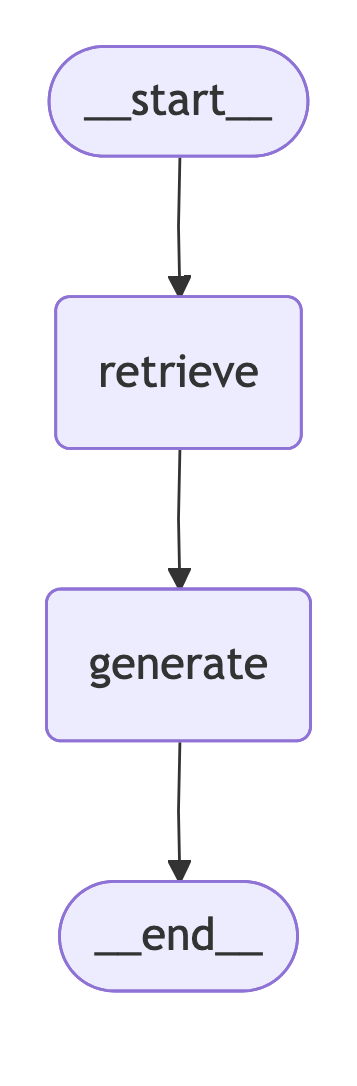

In [35]:
from IPython.display import Image, display
from langchain_core.runnables.graph import CurveStyle, MermaidDrawMethod, NodeStyles

display(
    Image(
        graph.get_graph().draw_mermaid_png(
            curve_style=CurveStyle.LINEAR,
            node_colors=NodeStyles(first="#ffdfba", last="#baffc9", default="#fad7de"),
            wrap_label_n_words=9,
            output_file_path=None,
            draw_method=MermaidDrawMethod.PYPPETEER,
            background_color="white",
            padding=10,
        )
    )
)

Let's do a test to make sure it's doing what we'd expect.

In [18]:
response = graph.invoke({"question" : "What are the different kinds of loans?"})

In [19]:
response["response"]

'The provided context does not contain information about the different kinds of loans.'

## Evaluating the App with Ragas

Now we can finally do our evaluation!

We'll start by running the queries we generated usign SDG above through our application to get context and responses.

In [20]:
for test_row in dataset:
  response = graph.invoke({"question" : test_row.eval_sample.user_input})
  test_row.eval_sample.response = response["response"]
  test_row.eval_sample.retrieved_contexts = [context.page_content for context in response["context"]]

In [21]:
dataset.samples[0].eval_sample.response

'Based on the provided context, there are approximately 40,000 ChatGPT users from May 2024. However, there is no specific information about the number of users in July 2025 or the number of messages sent every week.'

Then we can convert that table into a `EvaluationDataset` which will make the process of evaluation smoother.

In [22]:
from ragas import EvaluationDataset

evaluation_dataset = EvaluationDataset.from_pandas(dataset.to_pandas())

We'll need to select a judge model - in this case we're using the same model that was used to generate our Synthetic Data.

In [23]:
from ragas import evaluate
from ragas.llms import LangchainLLMWrapper

evaluator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4.1-mini"))

Next up - we simply evaluate on our desired metrics!

In [24]:
from ragas.metrics import LLMContextRecall, Faithfulness, FactualCorrectness, ResponseRelevancy, ContextEntityRecall, NoiseSensitivity
from ragas import evaluate, RunConfig

custom_run_config = RunConfig(timeout=360)

baseline_result = evaluate(
    dataset=evaluation_dataset,
    metrics=[LLMContextRecall(), Faithfulness(), FactualCorrectness(), ResponseRelevancy(), ContextEntityRecall(), NoiseSensitivity()],
    llm=evaluator_llm,
    run_config=custom_run_config
)
baseline_result

Evaluating:   0%|          | 0/48 [00:00<?, ?it/s]

{'context_recall': 0.2313, 'faithfulness': 0.6986, 'factual_correctness': 0.2375, 'answer_relevancy': 0.2229, 'context_entity_recall': 0.1194, 'noise_sensitivity_relevant': 0.1250}

## Making Adjustments and Re-Evaluating

Now that we've got our baseline - let's make a change and see how the model improves or doesn't improve!

> NOTE: This will be using Cohere's Rerank model - please be sure to [sign-up for an API key!](https://docs.cohere.com/reference/about)

In [25]:
os.environ["COHERE_API_KEY"] = getpass("Please enter your Cohere API key!")


We'll first set our retriever to return more documents, which will allow us to take advantage of the reranking.

In [26]:
text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=30)
split_documents = text_splitter.split_documents(docs)
len(split_documents)

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

client = QdrantClient(":memory:")

client.create_collection(
    collection_name="use_case_data_new_chunks",
    vectors_config=VectorParams(size=1536, distance=Distance.COSINE),
)

vector_store = QdrantVectorStore(
    client=client,
    collection_name="use_case_data_new_chunks",
    embedding=embeddings,
)

_ = vector_store.add_documents(documents=split_documents)

adjusted_example_retriever = vector_store.as_retriever(search_kwargs={"k": 20})

Reranking, or contextual compression, is a technique that uses a reranker to compress the retrieved documents into a smaller set of documents.

This is essentially a slower, more accurate form of semantic similarity that we use on a smaller subset of our documents.

In [27]:
from langchain.retrievers.contextual_compression import ContextualCompressionRetriever
from langchain_cohere import CohereRerank

def retrieve_adjusted(state):
  compressor = CohereRerank(model="rerank-v3.5")
  compression_retriever = ContextualCompressionRetriever(
    base_compressor=compressor, base_retriever=adjusted_example_retriever, search_kwargs={"k": 5}
  )
  retrieved_docs = compression_retriever.invoke(state["question"])
  return {"context" : retrieved_docs}

We can simply rebuild our graph with the new retriever!

In [28]:
class AdjustedState(TypedDict):
  question: str
  context: List[Document]
  response: str

adjusted_graph_builder = StateGraph(AdjustedState).add_sequence([retrieve_adjusted, generate])
adjusted_graph_builder.add_edge(START, "retrieve_adjusted")
adjusted_graph = adjusted_graph_builder.compile()

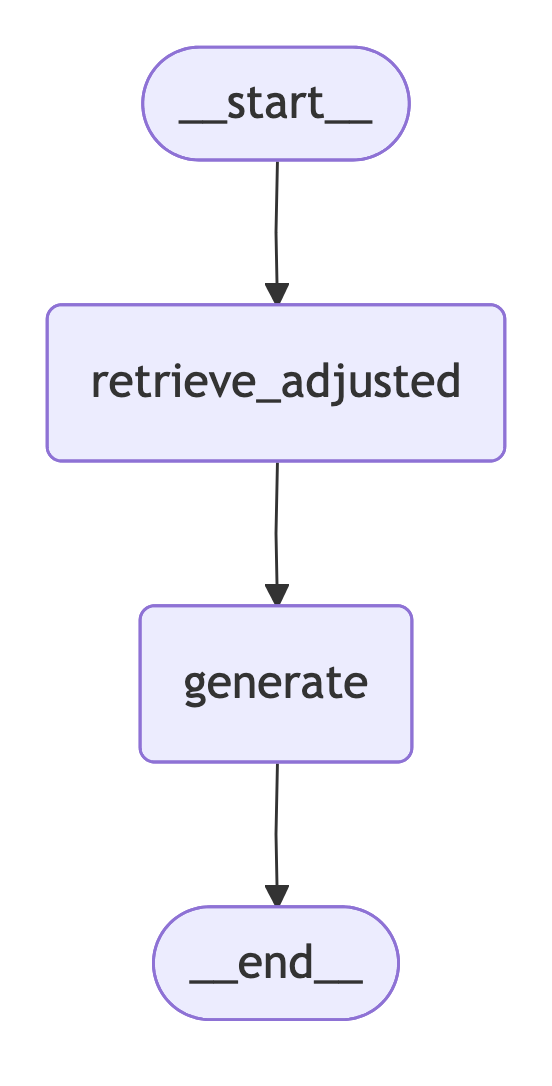

In [29]:
from IPython.display import Image, display
from langchain_core.runnables.graph import CurveStyle, MermaidDrawMethod, NodeStyles

display(
    Image(
        adjusted_graph.get_graph().draw_mermaid_png(
            curve_style=CurveStyle.LINEAR,
            node_colors=NodeStyles(first="#ffdfba", last="#baffc9", default="#fad7de"),
            wrap_label_n_words=9,
            output_file_path=None,
            draw_method=MermaidDrawMethod.PYPPETEER,
            background_color="white",
            padding=10,
        )
    )
)

In [30]:
response = adjusted_graph.invoke({"question" : "What are the different kinds of loans?"})
response["response"]

'The provided context does not mention or describe different kinds of loans.'

In [31]:
import time
import copy

rerank_dataset = copy.deepcopy(dataset)

for test_row in rerank_dataset:
  response = adjusted_graph.invoke({"question" : test_row.eval_sample.user_input})
  test_row.eval_sample.response = response["response"]
  test_row.eval_sample.retrieved_contexts = [context.page_content for context in response["context"]]
  time.sleep(2) # To try to avoid rate limiting.

In [32]:
rerank_dataset.samples[0].eval_sample.response

'In July 2025, more than 700 million people used ChatGPT weekly. Additionally, users collectively sent more than 18 billion messages each week during that month.'

In [33]:
rerank_evaluation_dataset = EvaluationDataset.from_pandas(rerank_dataset.to_pandas())

In [34]:
rerank_result = evaluate(
    dataset=rerank_evaluation_dataset,
    metrics=[LLMContextRecall(), Faithfulness(), FactualCorrectness(), ResponseRelevancy(), ContextEntityRecall(), NoiseSensitivity()],
    llm=evaluator_llm,
    run_config=custom_run_config
)
rerank_result

Evaluating:   0%|          | 0/48 [00:00<?, ?it/s]

{'context_recall': 0.7312, 'faithfulness': 0.8787, 'factual_correctness': 0.5437, 'answer_relevancy': 0.9344, 'context_entity_recall': 0.3417, 'noise_sensitivity_relevant': 0.2785}

#### ❓ Question: 

Which system performed better, on what metrics, and why?

## System Performance Comparison - Baseline vs Reranked 

**The reranked system performed significantly better across ALL metrics:**

| Metric | Baseline | Reranked | Improvement |
|--------|----------|----------|-------------|
| Context Recall | 0.2313 | 0.7312 | +216% |
| Faithfulness | 0.6986 | 0.8787 | +26% |
| Factual Correctness | 0.2375 | 0.5437 | +129% |
| Answer Relevancy | 0.2229 | 0.9344 | +319% |
| Context Entity Recall | 0.1194 | 0.3417 | +186% |
| Noise Sensitivity | 0.1250 | 0.2785 | +123% |

## Key Improvements

### Most Dramatic Improvements:
1. **Answer Relevancy**: 0.2229 → 0.9344 (+319%)
2. **Context Recall**: 0.2313 → 0.7312 (+216%)
3. **Context Entity Recall**: 0.1194 → 0.3417 (+186%)

### Moderate but Important Improvements:
4. **Factual Correctness**: 0.2375 → 0.5437 (+129%)
5. **Noise Sensitivity**: 0.1250 → 0.2785 (+123%)
6. **Faithfulness**: 0.6986 → 0.8787 (+26%)

## Why the Reranked System Performed Better

### 1. **Improved Chunking Strategy**
- **Baseline**: `chunk_size=50, chunk_overlap=0`
- **Reranked**: `chunk_size=500, chunk_overlap=30`
- **Impact**: Larger chunks with overlap preserved more context and semantic meaning

### 2. **Enhanced Retrieval Process**
- **Baseline**: Retrieved 3 documents directly
- **Reranked**: Retrieved 20 documents, then reranked to top 5 using Cohere's rerank-v3.5
- **Impact**: Cast a wider net initially, then used sophisticated reranking to select the most relevant chunks

### 3. **Semantic Reranking**
- **Cohere's rerank-v3.5** provided more accurate semantic similarity assessment than pure vector similarity
- **Contextual compression** ensured only the most relevant information was passed to the generation step

## Analysis by Metric

### **Answer Relevancy (319% improvement)**
- The most dramatic improvement indicates the reranked system generated much more relevant responses
- Better chunk selection led to more focused, on-topic answers

### **Context Recall (216% improvement)**
- Significantly better at retrieving relevant context from the knowledge base
- Larger chunks + reranking captured more complete information

### **Context Entity Recall (186% improvement)**
- Much better at identifying and retrieving specific entities mentioned in questions
- Reranking helped surface chunks containing relevant named entities

### **Factual Correctness (129% improvement)**
- More accurate factual information in responses
- Better context retrieval led to more factually grounded answers

### **Faithfulness (26% improvement)**
- Modest but important improvement in staying true to source material
- Even the baseline was relatively good at this (0.6986), so less room for improvement

## Conclusion

The reranked system's superior performance demonstrates the power of:
1. **Proper chunking strategy** (larger chunks with overlap)
2. **Two-stage retrieval** (broad retrieval + semantic reranking)
3. **Advanced reranking models** (Cohere's rerank-v3.5)

The improvements across all metrics, particularly the dramatic gains in answer relevancy and context recall, show that these optimizations created a fundamentally better RAG system that retrieves more relevant information and generates more accurate, helpful responses.